In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

import joblib
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Step 2 – Load the Dataset

We use the **California Housing Dataset** built into scikit-learn.  
It contains real housing data from California census blocks.

**Target variable:** `MedHouseVal` (median house value in $100,000s)

In [2]:
# Load dataset
data = fetch_california_housing(as_frame=True)

# Combine features + target into one DataFrame
df = pd.concat([data.data, data.target.rename('HousePrice')], axis=1)

print(f'Dataset shape: {df.shape}')
print(f'\nColumn names: {list(df.columns)}')
df.head()

Dataset shape: (20640, 9)

Column names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'HousePrice']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


---
## Step 3 – Exploratory Data Analysis (EDA)

Before training any model, always **understand your data**.

> 💡 *EDA helps catch missing values, outliers, and feature distributions early.*

In [3]:
# --- 3a. Basic statistics ---
print('=== Dataset Summary ===')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.describe().round(2)

=== Dataset Summary ===
Rows: 20,640  |  Columns: 9


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [4]:
# --- 3b. Check for missing values ---
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing: {missing.sum()} ✅' if missing.sum() == 0 else f'\n⚠️ Fix missing values before training!')

=== Missing Values ===
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
HousePrice    0
dtype: int64

Total missing: 0 ✅


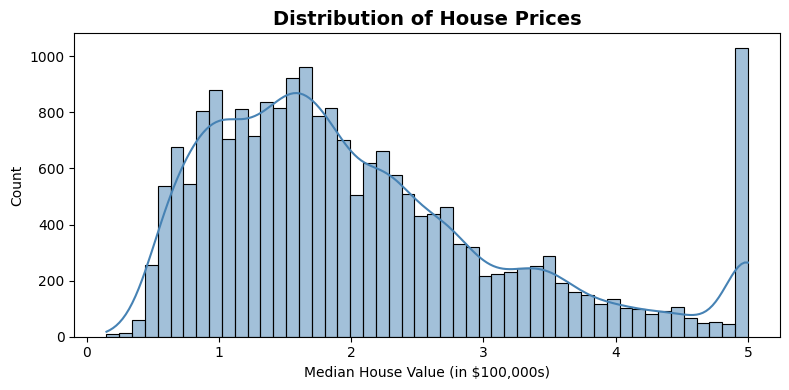

Mean house price: $206,856


In [5]:
# --- 3c. Distribution of target variable ---
plt.figure(figsize=(8, 4))
sns.histplot(df['HousePrice'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of House Prices', fontsize=14, fontweight='bold')
plt.xlabel('Median House Value (in $100,000s)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()
print(f'Mean house price: ${df["HousePrice"].mean()*100000:,.0f}')

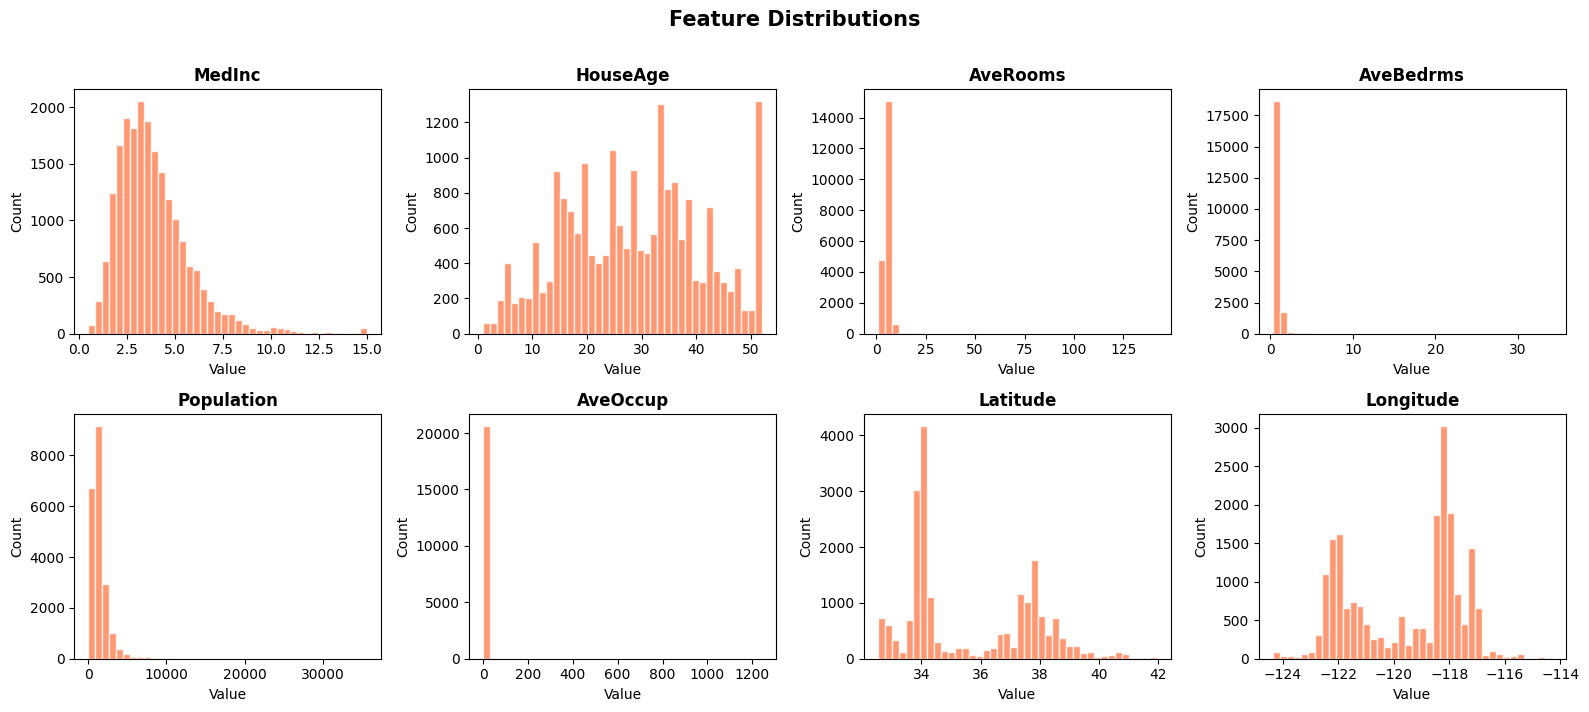

📊 Notice that features exist on VERY different numeric scales — this is why we need Feature Scaling!


In [6]:
# --- 3d. Feature distributions ---
features = [c for c in df.columns if c != 'HousePrice']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=40, color='coral', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()
print('📊 Notice that features exist on VERY different numeric scales — this is why we need Feature Scaling!')

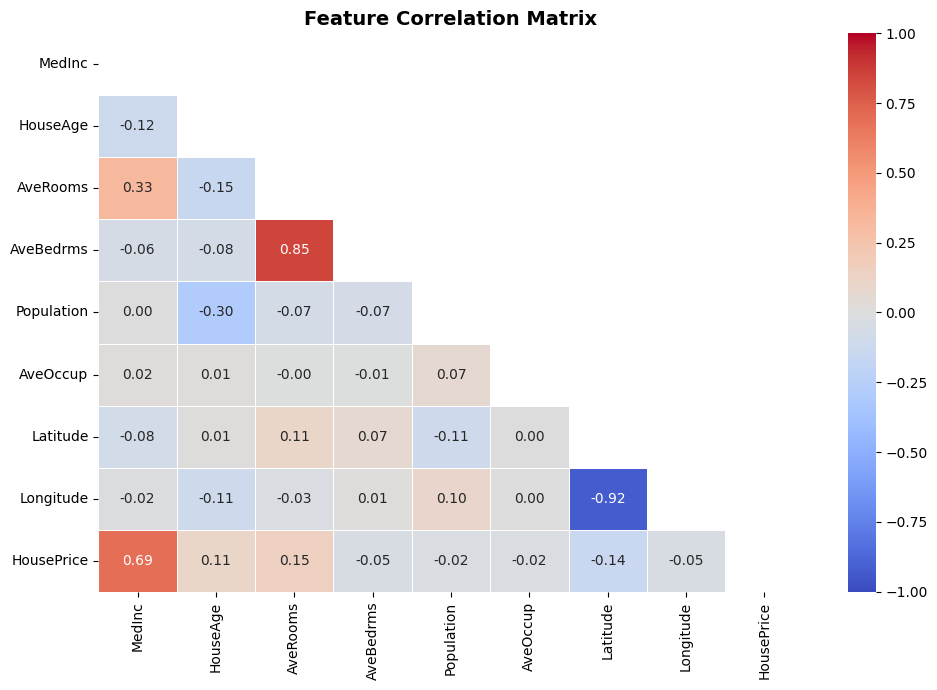

✅ MedInc (Median Income) has the highest correlation with HousePrice: 0.69


In [7]:
# --- 3e. Correlation heatmap ---
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'✅ MedInc (Median Income) has the highest correlation with HousePrice: {corr["HousePrice"]["MedInc"]:.2f}')

---
## Step 4 – Separate Features and Target Variable

- **X** = Input features (what the model learns from)
- **y** = Target variable (what the model predicts)

In [10]:
X = df.drop('HousePrice', axis=1)  # All columns except target
y = df['HousePrice']               # Target column

print(f'Feature matrix X shape: {X.shape}')
print(f'Target vector y shape:  {y.shape}')
print(f'\nFeatures used: {list(X.columns)}')

Feature matrix X shape: (20640, 8)
Target vector y shape:  (20640,)

Features used: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


---
## Step 5 – Feature Scaling *(Critical Step)*

Features like `Population` (up to 35,000) and `HouseAge` (1–52) are on completely different scales.

**Without scaling:**
- Large-value features dominate the model
- Distance-based algorithms perform poorly
- Gradient descent converges slowly

**Solution:** `StandardScaler` transforms each feature to have **mean = 0** and **std = 1**.

> ⚠️ Important rule: **Fit the scaler ONLY on training data**, then transform both train and test sets.
> This prevents data leakage.

In [11]:
# Before scaling
print('=== Feature Statistics BEFORE Scaling ===')
print(df.drop('HousePrice', axis=1).describe().loc[['mean', 'std', 'min', 'max']].round(2))

=== Feature Statistics BEFORE Scaling ===
      MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
mean    3.87     28.64      5.43       1.10     1425.48      3.07     35.63   
std     1.90     12.59      2.47       0.47     1132.46     10.39      2.14   
min     0.50      1.00      0.85       0.33        3.00      0.69     32.54   
max    15.00     52.00    141.91      34.07    35682.00   1243.33     41.95   

      Longitude  
mean    -119.57  
std        2.00  
min     -124.35  
max     -114.31  


In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for display
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('=== Feature Statistics AFTER Scaling ===')
print(X_scaled_df.describe().loc[['mean', 'std', 'min', 'max']].round(2))
print('\n✅ All features now have mean ≈ 0 and std ≈ 1 — fair learning ground!')

=== Feature Statistics AFTER Scaling ===
      MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
mean    0.00      0.00      0.00      -0.00       -0.00      0.00      0.00   
std     1.00      1.00      1.00       1.00        1.00      1.00      1.00   
min    -1.77     -2.20     -1.85      -1.61       -1.26     -0.23     -1.45   
max     5.86      1.86     55.16      69.57       30.25    119.42      2.96   

      Longitude  
mean      -0.00  
std        1.00  
min       -2.39  
max        2.63  

✅ All features now have mean ≈ 0 and std ≈ 1 — fair learning ground!


---
## Step 6 – Train–Test Split

We split the data into **80% training** and **20% testing**.

- **Training set:** The model learns patterns from this
- **Test set:** Unseen data used to evaluate real-world performance

We set `random_state=42` for reproducibility.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f'Training samples:  {X_train.shape[0]:,}  ({X_train.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'Testing samples:   {X_test.shape[0]:,}  ({X_test.shape[0]/len(X_scaled)*100:.0f}%)')
print(f'\n✅ Model will be evaluated on {X_test.shape[0]:,} unseen samples it never trained on.')

Training samples:  16,512  (80%)
Testing samples:   4,128  (20%)

✅ Model will be evaluated on 4,128 unseen samples it never trained on.


---
## Step 7 – Train Multiple Models

We train **3 different algorithms** and compare them:

| Model | Why we use it |
|---|---|
| **Linear Regression** | Baseline — simple, fast, interpretable |
| **Ridge Regression** | Adds regularization to reduce overfitting |
| **Decision Tree** | Captures non-linear patterns in data |

In [14]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Decision Tree':     DecisionTreeRegressor(max_depth=5)
}

print('Training models...')
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'  ✅ {name} trained')

print('\nAll models trained successfully!')

Training models...
  ✅ Linear Regression trained
  ✅ Ridge Regression trained
  ✅ Decision Tree trained

All models trained successfully!


---
## Step 8 – Evaluate & Compare Models

We measure each model using:

- **RMSE (Root Mean Squared Error):** Average prediction error in the same units as the target. **Lower is better.**
- **R² Score (Coefficient of Determination):** How much variance the model explains. **Closer to 1.0 is better.**

In [15]:
results = {}

for name, model in models.items():
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    results[name] = {'RMSE': round(rmse, 4), 'R² Score': round(r2, 4)}

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R² Score', ascending=False)

print('=== Model Performance Comparison ===')
print(results_df.to_string())

best_model_name = results_df['R² Score'].idxmax()
print(f'\n🏆 Best performing model: {best_model_name}')
print(f'   R² Score : {results_df.loc[best_model_name, "R² Score"]}')
print(f'   RMSE     : {results_df.loc[best_model_name, "RMSE"]}')

=== Model Performance Comparison ===
                     RMSE  R² Score
Decision Tree      0.7242    0.5997
Linear Regression  0.7456    0.5758
Ridge Regression   0.7456    0.5758

🏆 Best performing model: Decision Tree
   R² Score : 0.5997
   RMSE     : 0.7242


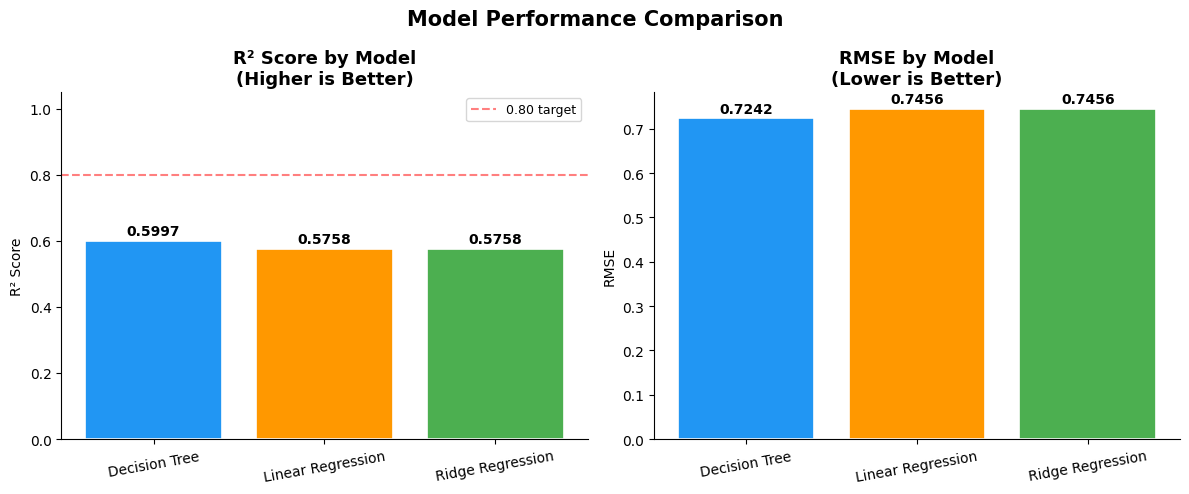

In [16]:
# --- Bar chart comparison ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['#2196F3', '#FF9800', '#4CAF50']

# R² Score
bars1 = axes[0].bar(results_df.index, results_df['R² Score'], color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('R² Score by Model\n(Higher is Better)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(0, 1.05)
axes[0].axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='0.80 target')
axes[0].legend(fontsize=9)
for bar, val in zip(bars1, results_df['R² Score']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

# RMSE
bars2 = axes[1].bar(results_df.index, results_df['RMSE'], color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('RMSE by Model\n(Lower is Better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('RMSE')
for bar, val in zip(bars2, results_df['RMSE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=10)

for ax in axes:
    ax.tick_params(axis='x', rotation=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 9 – Visual Performance Validation

**Actual vs Predicted plot:**
- Each dot is one house from the test set
- Perfect predictions → all dots fall on the red diagonal line
- Scatter away from the line = prediction error

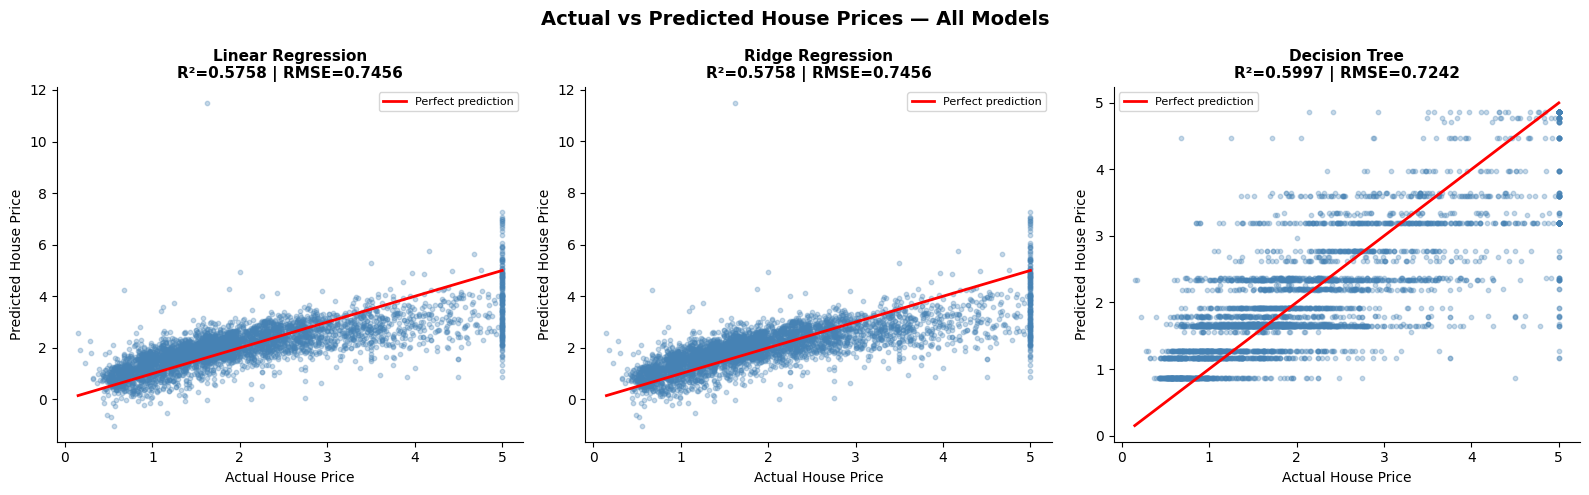

💡 Points closer to the red line = more accurate predictions


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    r2 = results[name]['R² Score']
    rmse = results[name]['RMSE']

    ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
    # Perfect prediction line
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], color='red', linewidth=2, label='Perfect prediction')

    ax.set_xlabel('Actual House Price')
    ax.set_ylabel('Predicted House Price')
    ax.set_title(f'{name}\nR²={r2} | RMSE={rmse}', fontweight='bold', fontsize=11)
    ax.legend(fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Actual vs Predicted House Prices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('💡 Points closer to the red line = more accurate predictions')

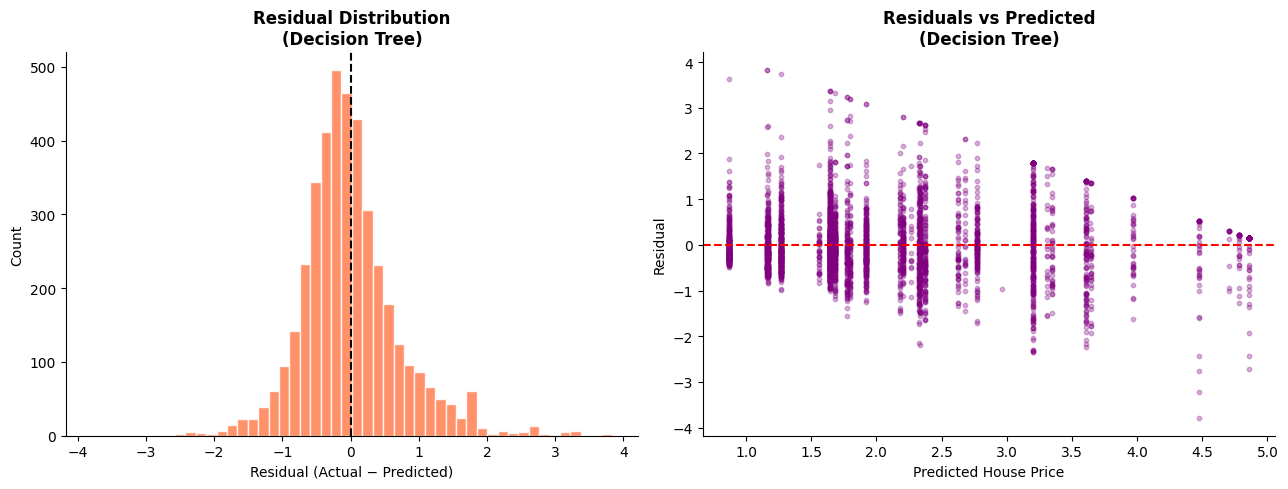

Mean residual: -0.0019 (ideal = 0.0)
✅ Residuals centered around 0 = no systematic bias in predictions


In [18]:
# --- Residual analysis for best model ---
best_model = models[best_model_name]
y_pred_best = best_model.predict(X_test)
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residual distribution
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='black', linestyle='--', linewidth=1.5)
axes[0].set_title(f'Residual Distribution\n({best_model_name})', fontweight='bold')
axes[0].set_xlabel('Residual (Actual − Predicted)')
axes[0].set_ylabel('Count')

# Residuals vs Predicted
axes[1].scatter(y_pred_best, residuals, alpha=0.3, s=10, color='purple')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title(f'Residuals vs Predicted\n({best_model_name})', fontweight='bold')
axes[1].set_xlabel('Predicted House Price')
axes[1].set_ylabel('Residual')

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print(f'Mean residual: {residuals.mean():.4f} (ideal = 0.0)')
print('✅ Residuals centered around 0 = no systematic bias in predictions')

---
## Step 10 – Save Best Model *(Optional)*

We use `joblib` to serialize and save the best-performing model for future use.

In [19]:
# Save best model and scaler
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f'✅ Best model ({best_model_name}) saved as best_model.pkl')
print('✅ Scaler saved as scaler.pkl')

# --- How to reload and use ---
print('\n--- How to load and use later ---')
print("  loaded_model  = joblib.load('best_model.pkl')")
print("  loaded_scaler = joblib.load('scaler.pkl')")
print("  new_X_scaled  = loaded_scaler.transform(new_data)")
print("  predictions   = loaded_model.predict(new_X_scaled)")

✅ Best model (Decision Tree) saved as best_model.pkl
✅ Scaler saved as scaler.pkl

--- How to load and use later ---
  loaded_model  = joblib.load('best_model.pkl')
  loaded_scaler = joblib.load('scaler.pkl')
  new_X_scaled  = loaded_scaler.transform(new_data)
  predictions   = loaded_model.predict(new_X_scaled)


---
## Step 11 – Conclusion & Model Selection

### Summary Table

In [20]:
print('=' * 55)
print('       FINAL MODEL PERFORMANCE COMPARISON')
print('=' * 55)
print(f'{"Model":<25} {"RMSE":>10} {"R² Score":>10}')
print('-' * 55)
for idx, row in results_df.iterrows():
    tag = ' 🏆' if idx == best_model_name else ''
    print(f'{idx:<25} {row["RMSE"]:>10.4f} {row["R² Score"]:>10.4f}{tag}')
print('=' * 55)
print(f'\n✅ SELECTED MODEL: {best_model_name}')
print()
print('JUSTIFICATION:')
print(f'  • Highest R² Score ({results_df.loc[best_model_name, "R² Score"]}) — explains more variance')
print(f'  • Lowest RMSE ({results_df.loc[best_model_name, "RMSE"]}) — smaller average prediction error')
print(f'  • Captures non-linear relationships in the housing data')
print(f'  • max_depth=5 prevents overfitting')
print()
print('KEY LEARNINGS FROM THIS TASK:')
print('  ✔ Feature scaling is essential before training')
print('  ✔ No single algorithm is always best — compare multiple')
print('  ✔ RMSE and R² together give a complete performance picture')
print('  ✔ Visual plots help confirm metric-based findings')

       FINAL MODEL PERFORMANCE COMPARISON
Model                           RMSE   R² Score
-------------------------------------------------------
Decision Tree                 0.7242     0.5997 🏆
Linear Regression             0.7456     0.5758
Ridge Regression              0.7456     0.5758

✅ SELECTED MODEL: Decision Tree

JUSTIFICATION:
  • Highest R² Score (0.5997) — explains more variance
  • Lowest RMSE (0.7242) — smaller average prediction error
  • Captures non-linear relationships in the housing data
  • max_depth=5 prevents overfitting

KEY LEARNINGS FROM THIS TASK:
  ✔ Feature scaling is essential before training
  ✔ No single algorithm is always best — compare multiple
  ✔ RMSE and R² together give a complete performance picture
  ✔ Visual plots help confirm metric-based findings
